## 1. Load Dataset

In [39]:
#pip install seaborn

In [40]:
import pandas as pd
sol_df = pd.read_csv("delaney.csv")

In [41]:
sol_df

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.180,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.000,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.740,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.480,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.040,-3.077,FC(F)(Cl)C(F)(Cl)Cl
...,...,...,...,...
1139,vamidothion,1.144,-1.446,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
1140,Vinclozolin,-4.925,-4.377,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C
1141,Warfarin,-3.893,-3.913,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O
1142,Xipamide,-3.790,-3.642,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O


# 2. Examine SMILES DATA

In [42]:
sol_df.SMILES

0                                    ClCC(Cl)(Cl)Cl
1                                      CC(Cl)(Cl)Cl
2                                    ClC(Cl)C(Cl)Cl
3                                        ClCC(Cl)Cl
4                               FC(F)(Cl)C(F)(Cl)Cl
                           ...                     
1139                   CNC(=O)C(C)SCCSP(=O)(OC)(OC)
1140          CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C
1141         CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O 
1142    Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O
1143                         CNC(=O)Oc1cc(C)cc(C)c1
Name: SMILES, Length: 1144, dtype: object

### 2.1 Convert a molecule from smiles string to rdkit object 

In [43]:
from rdkit import Chem
sol_df.SMILES[0]

'ClCC(Cl)(Cl)Cl'

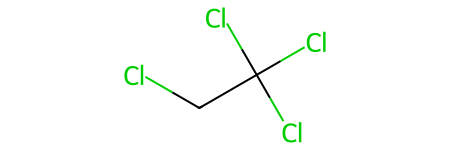

In [44]:
m=Chem.MolFromSmiles(sol_df.SMILES[0])
m

In [45]:
m.GetNumAtoms()

6

### 2.3 Functions to Convert all smiles string to rdkit object

In [46]:
mol_list = []
for elements in sol_df.SMILES:
    mol = Chem.MolFromSmiles(elements)
    if mol is not None:
        mol_list.append(mol)
    else:
        print(f"Invalid Smiles : {elements}")

In [47]:
len(mol_list)

1144

In [48]:
mol_list[:2]

In [49]:
type(mol_list)

list

In [50]:
mol_list2 = mol_list 

# 3. Calculate Molecular descriptor

## Five Main Descriptor:
### 1.cLogP (octanol-water partition coefficient)
### 2.MW (Molecular Weight)
### 3.RB (Number of Rotatable Bonds)
### 4.Ap (Aromatic proportion: Number of Aromatic Atoms/total number of heavy atoms)
### 5.TPSA (Topological Polar Surface Area) 
### 6.NumHdonors (Number of Hydrogen bond Donors)
### 7.NumHAcceptors (Number of Hydrogen bond Acceptors)

In [51]:
import numpy as np
from rdkit.Chem import Descriptors

def generate_descriptors(smiles_list, verbose=False):
    data = []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            if verbose:
                print(f"INVALID SMILES at index {i}: {smi}")
            continue

        desc = [
            Descriptors.MolLogP(mol),
            Descriptors.MolWt(mol),
            Descriptors.NumRotatableBonds(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol)
        ]

        data.append(desc)

    column_names = ["MolLogP", "MolWt", "NumRotatableBonds", "TPSA", "NumHDonors","NumHAcceptors"]
    descriptors_df = pd.DataFrame(data, columns=column_names)

    return descriptors_df

In [52]:
df = generate_descriptors(sol_df.SMILES)
df

,MolLogP,MolWt,NumRotatableBonds,TPSA,NumHDonors,NumHAcceptors
0,2.59540,167.850,0,0.00,0,0
1,2.37650,133.405,0,0.00,0,0
2,2.59380,167.850,1,0.00,0,0
3,2.02890,133.405,1,0.00,0,0
4,2.91890,187.375,1,0.00,0,0
...,...,...,...,...,...,...
1139,1.98820,287.343,8,64.63,1,6
1140,3.42130,286.114,2,46.61,0,3
1141,3.60960,308.333,4,67.51,1,4
1142,2.56214,354.815,3,109.49,3,4


## 3.2 Calculate Aromatic Proportion

In [53]:
def AromaticAtoms(m):
    aromatic_atoms = [m.GetAtomWithIdx(i).GetIsAromatic() for i in range(m.GetNumAtoms())]
    aa_count = []
    for i in aromatic_atoms:
        if i==True:
            aa_count.append(1)
    sum_aa_count = sum(aa_count)
    return sum_aa_count
                      

In [54]:
desc_AromaticAtoms = [AromaticAtoms(element) for element in mol_list]

## 3.2.1 Calculate Heavy Atoms

In [55]:
desc_HeavyAtomCount = [Descriptors.HeavyAtomCount(element) for element in mol_list]

## 3.2.1.1 Compute the Aromatic Proportion (AP) descriptor

In [56]:
des_AP = [AromaticAtoms(element)/Descriptors.HeavyAtomCount(element) for element in mol_list]

In [57]:
df_desc_AP = pd.DataFrame(des_AP, columns=['AromaticProportion'])

## 3.2.1.2 Combined Dataset

In [58]:
df

,MolLogP,MolWt,NumRotatableBonds,TPSA,NumHDonors,NumHAcceptors
0,2.59540,167.850,0,0.00,0,0
1,2.37650,133.405,0,0.00,0,0
2,2.59380,167.850,1,0.00,0,0
3,2.02890,133.405,1,0.00,0,0
4,2.91890,187.375,1,0.00,0,0
...,...,...,...,...,...,...
1139,1.98820,287.343,8,64.63,1,6
1140,3.42130,286.114,2,46.61,0,3
1141,3.60960,308.333,4,67.51,1,4
1142,2.56214,354.815,3,109.49,3,4


In [59]:
df_desc_AP

,AromaticProportion
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
1139,0.000000
1140,0.333333
1141,0.695652
1142,0.521739


In [60]:
X = pd.concat([df, df_desc_AP], axis=1)
X

,MolLogP,MolWt,NumRotatableBonds,TPSA,NumHDonors,NumHAcceptors,AromaticProportion
0,2.59540,167.850,0,0.00,0,0,0.000000
1,2.37650,133.405,0,0.00,0,0,0.000000
2,2.59380,167.850,1,0.00,0,0,0.000000
3,2.02890,133.405,1,0.00,0,0,0.000000
4,2.91890,187.375,1,0.00,0,0,0.000000
...,...,...,...,...,...,...,...
1139,1.98820,287.343,8,64.63,1,6,0.000000
1140,3.42130,286.114,2,46.61,0,3,0.333333
1141,3.60960,308.333,4,67.51,1,4,0.695652
1142,2.56214,354.815,3,109.49,3,4,0.521739


## 3.2.2 Y Matrix

In [61]:
Y = sol_df.iloc[:,1]
Y

0      -2.180
1      -2.000
2      -1.740
3      -1.480
4      -3.040
        ...  
1139    1.144
1140   -4.925
1141   -3.893
1142   -3.790
1143   -2.581
Name: measured log(solubility:mol/L), Length: 1144, dtype: float64

## Exploratory Data Analysis

In [64]:
df_combined

,MolLogP,MolWt,NumRotatableBonds,TPSA,NumHDonors,NumHAcceptors,AromaticProportion,Target
0,2.59540,167.850,0,0.00,0,0,0.000000,-2.180
1,2.37650,133.405,0,0.00,0,0,0.000000,-2.000
2,2.59380,167.850,1,0.00,0,0,0.000000,-1.740
3,2.02890,133.405,1,0.00,0,0,0.000000,-1.480
4,2.91890,187.375,1,0.00,0,0,0.000000,-3.040
...,...,...,...,...,...,...,...,...
1139,1.98820,287.343,8,64.63,1,6,0.000000,1.144
1140,3.42130,286.114,2,46.61,0,3,0.333333,-4.925
1141,3.60960,308.333,4,67.51,1,4,0.695652,-3.893
1142,2.56214,354.815,3,109.49,3,4,0.521739,-3.790


In [65]:
X

,MolLogP,MolWt,NumRotatableBonds,TPSA,NumHDonors,NumHAcceptors,AromaticProportion
0,2.59540,167.850,0,0.00,0,0,0.000000
1,2.37650,133.405,0,0.00,0,0,0.000000
2,2.59380,167.850,1,0.00,0,0,0.000000
3,2.02890,133.405,1,0.00,0,0,0.000000
4,2.91890,187.375,1,0.00,0,0,0.000000
...,...,...,...,...,...,...,...
1139,1.98820,287.343,8,64.63,1,6,0.000000
1140,3.42130,286.114,2,46.61,0,3,0.333333
1141,3.60960,308.333,4,67.51,1,4,0.695652
1142,2.56214,354.815,3,109.49,3,4,0.521739


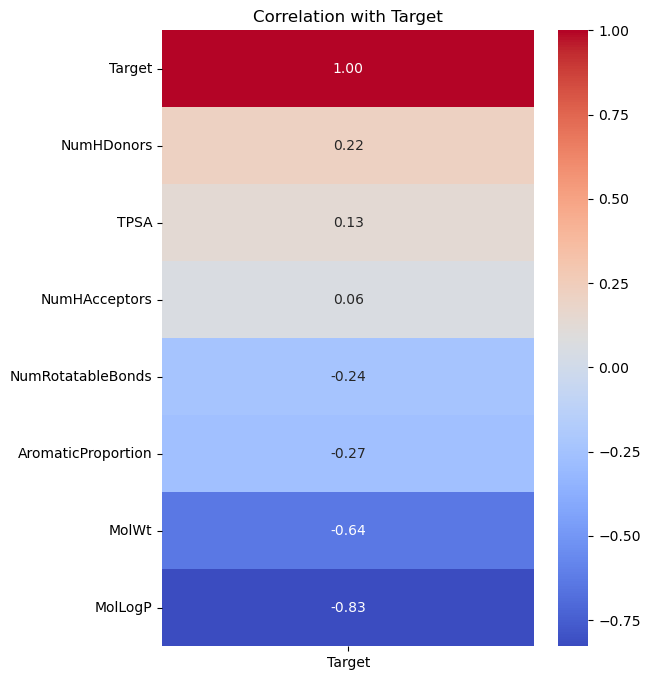

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

df_combined = X.copy()
df_combined["Target"] = Y

corr_matrix = df_combined.corr()

target_corr = corr_matrix["Target"].sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(target_corr.to_frame(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation with Target")
plt.show()

<Axes: >

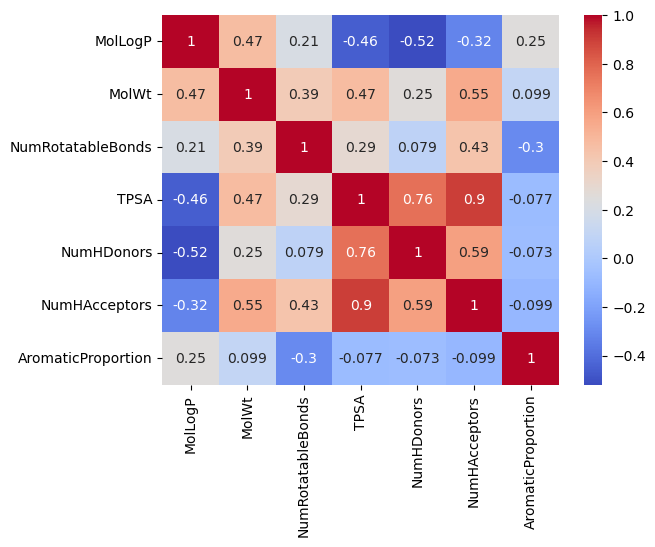

In [67]:
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')

In [86]:
X_original = X.copy()
#X = X.drop("NumHAcceptors", axis=1)


In [87]:
print(X.columns)

Index(['MolLogP', 'MolWt', 'NumRotatableBonds', 'TPSA', 'NumHDonors',
       'NumHAcceptors', 'AromaticProportion'],
      dtype='object')


In [88]:
print(X_original)

      MolLogP    MolWt  NumRotatableBonds    TPSA  NumHDonors  NumHAcceptors  \
0     2.59540  167.850                  0    0.00           0              0   
1     2.37650  133.405                  0    0.00           0              0   
2     2.59380  167.850                  1    0.00           0              0   
3     2.02890  133.405                  1    0.00           0              0   
4     2.91890  187.375                  1    0.00           0              0   
...       ...      ...                ...     ...         ...            ...   
1139  1.98820  287.343                  8   64.63           1              6   
1140  3.42130  286.114                  2   46.61           0              3   
1141  3.60960  308.333                  4   67.51           1              4   
1142  2.56214  354.815                  3  109.49           3              4   
1143  2.02164  179.219                  1   38.33           1              2   

      AromaticProportion  
0           

## 4 Splitting Data

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)

## 4.1 Linear Regression Model

In [69]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

model = linear_model.LinearRegression()
model.fit(X_train, Y_train)

#predicts the X_train
Y_pred_train = model.predict(X_train)


comparison = pd.DataFrame({
    "Measured_logs": Y_train,
    "Predicted_logs": Y_pred_train
})
print(comparison.head())

      Measured_logs  Predicted_logs
280          -6.301       -5.604156
147          -7.920       -7.273040
1083         -2.310       -2.597705
698          -4.047       -4.486370
73           -3.120       -2.651189


## 4.2 Training Result

In [70]:
print('Coefficients: ', model.coef_)
print('Intercept: ', model.intercept_)
print('Mean squared error (MSE): %.2f' % mean_squared_error(Y_train, Y_pred_train))
print('Coefficient of determination (R^2): %.2f' % r2_score(Y_train, Y_pred_train))

Coefficients:  [-0.83599197 -0.00567672 -0.00769494 -0.01070004 -0.12180244  0.17492711
 -0.40685983]
Intercept:  0.4097087263140029
Mean squared error (MSE): 0.96
Coefficient of determination (R^2): 0.79


## 4.3 Testing Model

In [71]:
Y_pred_test = model.predict(X_test)

In [72]:
test_vs_measured = pd.DataFrame({
    "Measured_logS": Y_test,
    "Predicted_logS": Y_pred_test
})
print(comparison.head())

      Measured_logs  Predicted_logs
280          -6.301       -5.604156
147          -7.920       -7.273040
1083         -2.310       -2.597705
698          -4.047       -4.486370
73           -3.120       -2.651189


## 4.3.1 Testing Result

In [74]:
print('coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean squared error (MSE): %.2f' % mean_squared_error(Y_test, Y_pred_test))
print('Coefficient of determination (R^2): %.2f' %r2_score(Y_test, Y_pred_test))

coefficients: [-0.83599197 -0.00567672 -0.00769494 -0.01070004 -0.12180244  0.17492711
 -0.40685983]
Intercept: 0.4097087263140029
Mean squared error (MSE): 0.96
Coefficient of determination (R^2): 0.73


## 4.4 Linear Regression Equation

In [79]:
print('LogS = %.2f %.2f LogP  %.4f MW  %.4f RB  %.4f TPSA  %.4f NumHDonors  %.4f NumHAcceptors  %.3fAP' % (model.intercept_, model.coef_[0], model.coef_[1], model.coef_[2], model.coef_[3], model.coef_[4], model.coef_[5], model.coef_[6] ) )

LogS = 0.41 -0.84 LogP  -0.0057 MW  -0.0077 RB  -0.0107 TPSA  -0.1218 NumHDonors  0.1749 NumHAcceptors  -0.407AP


In [75]:
print(X_test)

      MolLogP    MolWt  NumRotatableBonds   TPSA  NumHDonors  NumHAcceptors  \
580   3.99540  269.127                  2  40.46           2              2   
550   6.17798  416.304                  6  59.32           0              4   
86    2.36260   84.162                  3   0.00           0              0   
228   2.36260   84.162                  2   0.00           0              0   
1045  1.62880  313.361                  4  81.59           2              6   
...       ...      ...                ...    ...         ...            ...   
14    4.30020  215.894                  0   0.00           0              0   
972   1.60340  153.137                  2  52.37           0              3   
306   4.66040  223.102                  1   0.00           0              0   
1109  1.97250   70.135                  1   0.00           0              0   
20    3.21160  235.906                  0   0.00           0              0   

      AromaticProportion  
580             0.705882

# Data Visualization

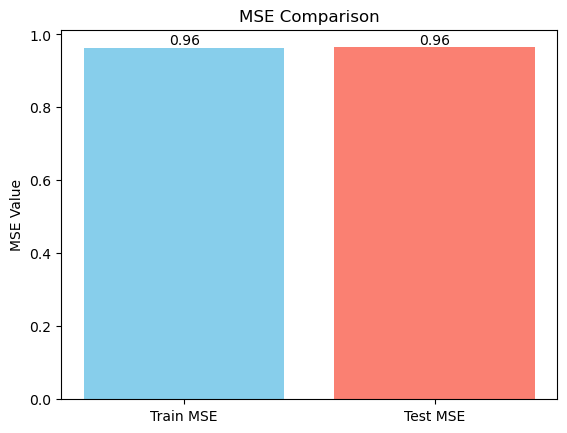

In [84]:
mse_train = mean_squared_error(Y_train, Y_pred_train)
mse_test = mean_squared_error(Y_test, Y_pred_test)

values = [mse_train, mse_test]
labels = ["Train MSE", "Test MSE"]
colors = ["skyblue", "salmon"]

plt.figure()
bars = plt.bar(labels, values, color=colors)

plt.title("MSE Comparison")
plt.ylabel("MSE Value")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             height, 
             f"{height:.2f}", 
             ha='center', 
             va='bottom')

plt.show()

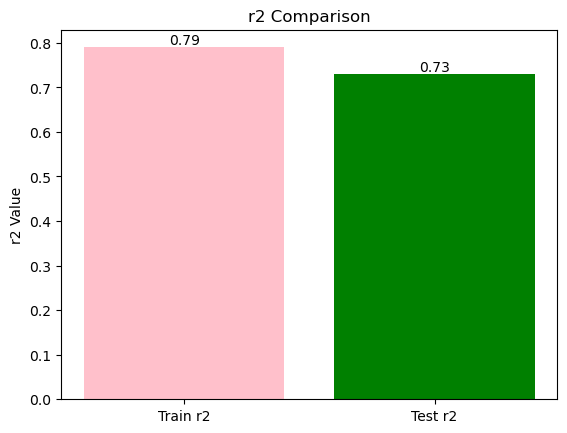

In [85]:
r2_train = r2_score(Y_train, Y_pred_train)
r2_test = r2_score(Y_test, Y_pred_test)

values = [r2_train, r2_test]
labels = ["Train r2", "Test r2"]
colors = ["pink", "green"]

plt.figure()
bars = plt.bar(labels, values, color=colors)

plt.title("r2 Comparison")
plt.ylabel("r2 Value")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             height, 
             f"{height:.2f}", 
             ha='center', 
             va='bottom')

plt.show()

## Training entire dataset (For Comaprison)

In [89]:
full = linear_model.LinearRegression()
full.fit(X,Y)
full_pred = model.predict(X)

print('Coefficients: ', full.coef_)
print('Intercept: ', full.intercept_)
print('Mean squared error (MSE): %.2f' % mean_squared_error (Y, full_pred))
print('Coefficient of determination (R^2): %.2f' %r2_score (Y, full_pred))

Coefficients:  [-0.85441105 -0.00523918 -0.00959829 -0.01212298 -0.12289596  0.17791624
 -0.35606292]
Intercept:  0.4005641020465136
Mean squared error (MSE): 0.96
Coefficient of determination (R^2): 0.78


In [90]:
print('LogS = %.2f %.2f LogP  %.4f MW  %.4f RB  %.4f TPSA  %.4f NumHDonors  %.4f NumHAcceptors  %.3fAP' % (full.intercept_, full.coef_[0], full.coef_[1], full.coef_[2], full.coef_[3], full.coef_[4], full.coef_[5], full.coef_[6] ) )

LogS = 0.40 -0.85 LogP  -0.0052 MW  -0.0096 RB  -0.0121 TPSA  -0.1229 NumHDonors  0.1779 NumHAcceptors  -0.356AP


# Scatter plot of experimental vs predicted LogS

In [92]:
Y_train.shape, Y_pred_train.shape

((915,), (915,))

In [93]:
Y_test.shape, Y_pred_test.shape

((229,), (229,))

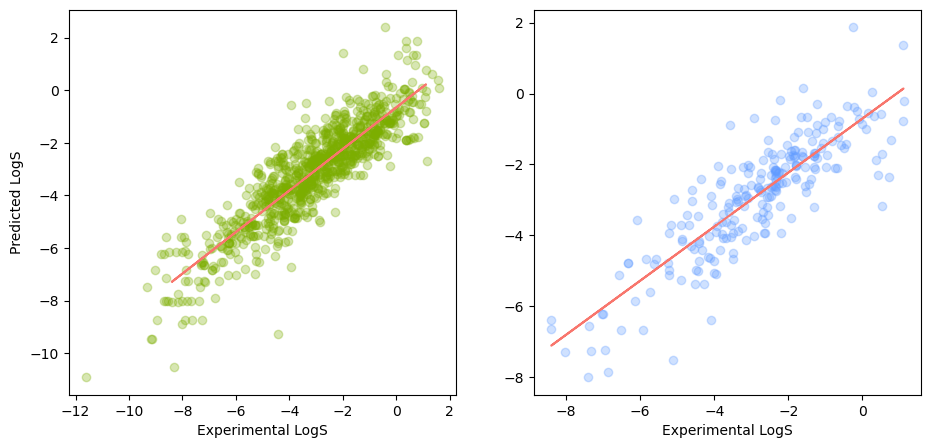

In [94]:
plt.figure(figsize=(11,5))

# 1 row, 2 column, plot 1
plt.subplot(1, 2, 1)
plt.scatter(x=Y_train, y=Y_pred_train, c="#7CAE00", alpha=0.3)

z = np.polyfit(Y_train, Y_pred_train, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")

plt.ylabel('Predicted LogS')
plt.xlabel('Experimental LogS')

# 1 row, 2 column, plot 2
plt.subplot(1, 2, 2)
plt.scatter(x=Y_test, y=Y_pred_test, c="#619CFF", alpha=0.3)

z = np.polyfit(Y_test, Y_pred_test, 1)
p = np.poly1d(z)
plt.plot(Y_test,p(Y_test),"#F8766D")

plt.xlabel('Experimental LogS')

plt.savefig('plot_horizontal_logS.png')
plt.savefig('plot_horizontal_logS.pdf')
plt.show()